# E-commerce Order Processing System

It includes features 
- Conditional Routing: Decisions based on data (e.g., Inventory checks).
- Cyclic Graphs (Loops): A retry mechanism for payment processing.
- State Management: Passing data between nodes without external LLMs.

Workflow logic 
1. Validate Order $\rightarrow$ If invalid, stop.
2. Check Inventory $\rightarrow$ If out of stock, stop.
3. Process Payment $\rightarrow$ If it fails, increment a counter and loop back to retry (up to 3 times).
4. Ship Order $\rightarrow$ Only if payment succeeds.
5. Send Email $\rightarrow$ Final step for both success and specific failure cases.

In [2]:
import random
from typing import TypedDict, Literal
from langgraph.graph import StateGraph, START, END

In [3]:
# --- 1. Define the State ---
# This dictionary carries the data through the graph nodes.
class OrderState(TypedDict):
    order_id: str
    items: list[str]
    is_valid: bool
    in_stock: bool
    payment_status: str
    retry_count: int
    final_message: str

In [4]:
# --- 2. Define the Nodes (Dummy Functions) ---
# These represent the work being done. No LLMs, just logic.

def validate_order(state: OrderState):
    """Checks if the order has items."""
    print(f"\n[1] Validating Order {state['order_id']}...")
    if not state["items"]:
        print(" -> Validation Failed: No items.")
        return {"is_valid": False}
    
    print(" -> Validation Successful.")
    return {"is_valid": True}

def check_inventory(state: OrderState):
    """Simulates checking stock."""
    print("[2] Checking Inventory...")
    # Simulate a random stock check (80% chance of being in stock)
    in_stock = random.random() < 0.8 
    
    if in_stock:
        print(" -> Items are in stock.")
        return {"in_stock": True}
    else:
        print(" -> Items are OUT OF STOCK.")
        return {"in_stock": False}

def process_payment(state: OrderState):
    """Simulates payment processing with potential failure."""
    current_retries = state.get("retry_count", 0)
    print(f"[3] Processing Payment (Attempt {current_retries + 1})...")
    
    # Simulate random payment success (60% chance)
    payment_success = random.random() < 0.6
    
    if payment_success:
        print(" -> Payment Approved.")
        return {"payment_status": "success"}
    else:
        print(" -> Payment Failed.")
        return {"payment_status": "failed", "retry_count": current_retries + 1}

def ship_order(state: OrderState):
    """Simulates shipping."""
    print("[4] Shipping Order...")
    return {"final_message": "Order Shipped Successfully!"}

def send_failure_notification(state: OrderState):
    """Handles failures (validation, stock, or max retries)."""
    reason = "Unknown"
    if not state.get("is_valid"): reason = "Invalid Order"
    elif not state.get("in_stock"): reason = "Out of Stock"
    elif state.get("payment_status") == "failed": reason = "Payment Failed after Retries"
    
    print(f"[X] Sending Failure Notification: {reason}")
    return {"final_message": f"Order Cancelled: {reason}"}

In [5]:
# --- 3. Define Conditional Logic (Edges) ---
# These functions determine which node to go to next.

def route_validation(state: OrderState) -> Literal["check_inventory", "send_failure_notification"]:
    if state["is_valid"]:
        return "check_inventory"
    return "send_failure_notification"

def route_inventory(state: OrderState) -> Literal["process_payment", "send_failure_notification"]:
    if state["in_stock"]:
        return "process_payment"
    return "send_failure_notification"

def route_payment(state: OrderState) -> Literal["ship_order", "process_payment", "send_failure_notification"]:
    status = state["payment_status"]
    retries = state["retry_count"]
    
    if status == "success":
        return "ship_order"
    elif retries < 3:
        # COMPLEXITY: This creates a cycle/loop in the graph
        print(f"    !!! Retrying payment... ({3 - retries} attempts left)")
        return "process_payment"
    else:
        return "send_failure_notification"

In [6]:
# --- 4. Build the Graph ---
builder = StateGraph(OrderState)

# Add Nodes
builder.add_node("validate_order", validate_order)
builder.add_node("check_inventory", check_inventory)
builder.add_node("process_payment", process_payment)
builder.add_node("ship_order", ship_order)
builder.add_node("send_failure_notification", send_failure_notification)



In [7]:
# Add Edges
# Start -> Validate
builder.add_edge(START, "validate_order")

# Validate -> (Inventory OR Fail)
builder.add_conditional_edges("validate_order", route_validation)

# Inventory -> (Payment OR Fail)
builder.add_conditional_edges("check_inventory",route_inventory)


# Payment -> (Ship OR Retry Loop OR Fail)
builder.add_conditional_edges("process_payment",route_payment)

# Ship -> End
builder.add_edge("ship_order", END)

# Fail -> End
builder.add_edge("send_failure_notification", END)

In [8]:
# Compile
graph = builder.compile()

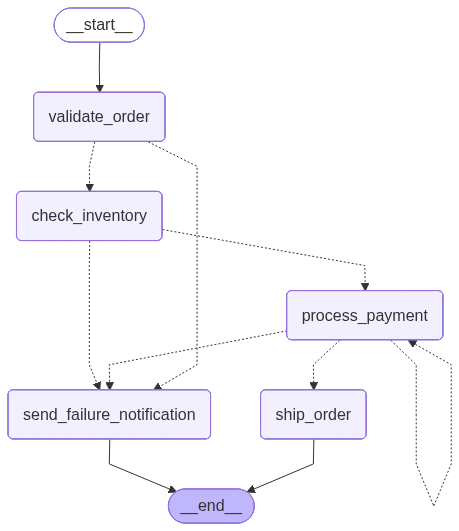

In [9]:
# Order Processing System Process Graph Visualization
from IPython.display import Image, display

# Using the 'graph' object from the previous code
try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    # Fallback if dependencies (like graphviz) aren't installed
    print(graph.get_graph().draw_ascii())

### Example 1 : Standard Order = Valid Order

In [10]:
# Example 1: A standard order
print("--- RUNNING WORKFLOW (Simulated) ---")
initial_state = {
    "order_id": "ORD-123",
    "items": ["Laptop", "Mouse"],
    "is_valid": False,
    "in_stock": False,
    "payment_status": "pending",
    "retry_count": 0,
    "final_message": ""
}


try:
    final_state = graph.invoke(initial_state)
    print("\n--- WORKFLOW COMPLETE ---")
    print("Final Status Message:", final_state["final_message"])
except Exception as e:
    print(e)

--- RUNNING WORKFLOW (Simulated) ---

[1] Validating Order ORD-123...
 -> Validation Successful.
[2] Checking Inventory...
 -> Items are OUT OF STOCK.
[X] Sending Failure Notification: Out of Stock

--- WORKFLOW COMPLETE ---
Final Status Message: Order Cancelled: Out of Stock


### Example 2 : Invalid Order = item not available

In [11]:
# Example 1: A standard order
print("--- RUNNING WORKFLOW (Simulated) ---")
initial_state = {
    "order_id": "",
    "items": [],
    "is_valid": False,
    "in_stock": False,
    "payment_status": "pending",
    "retry_count": 0,
    "final_message": ""
}


try:
    final_state = graph.invoke(initial_state)
    print("\n--- WORKFLOW COMPLETE ---")
    print("Final Status Message:", final_state["final_message"])
except Exception as e:
    print(e)

--- RUNNING WORKFLOW (Simulated) ---

[1] Validating Order ...
 -> Validation Failed: No items.
[X] Sending Failure Notification: Invalid Order

--- WORKFLOW COMPLETE ---
Final Status Message: Order Cancelled: Invalid Order
